##### F2 — K-means Cluster Analysis (Noisy Bayesian Optimization, 2D)

##### Purpose

F2 is the project's case of **multimodal structure**. Two geographically separated regions have produced high-y values:

##### Function: F2 — Noisy BO, 2D
- Domain: [0,1]²
- Y range: bounded (~ -0.07 to +0.72)
- Preprocessing for clustering: raw y (no transformation needed)
- Known structure: BIMODAL, NOISY

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load F2 data
data = np.load('F2_data.npz')
X = data['X']
y = data['y']

print(f"F2 dataset: {len(X)} points")
print(f"  y range: [{y.min():.4f}, {y.max():.4f}]")
print(f"  Best:    X={X[y.argmax()]}, y={y.max():.4f}")
print(f"  Top 3 y values:")
for idx in np.argsort(y)[-3:][::-1]:
    print(f"    X={X[idx]}, y={y[idx]:.4f}")

F2 dataset: 22 points
  y range: [-0.0656, 0.7334]
  Best:    X=[0.8726 0.435 ], y=0.7334
  Top 3 y values:
    X=[0.8726 0.435 ], y=0.7334
    X=[0.8726 0.43  ], y=0.7184
    X=[0.7026 0.75  ], y=0.6507


##### Step 1 — K-means with silhouette analysis

F2's known bimodality should produce a k=2 silhouette winner.
We test k=2, 3, 4 to confirm.

In [7]:
sil_scores = {}
for k in range(2, 5):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    sil_scores[k] = silhouette_score(X, km.labels_)
    print(f"  k={k}: silhouette = {sil_scores[k]:+.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n→ Natural cluster count: k = {best_k}")

  k=2: silhouette = +0.4493
  k=3: silhouette = +0.4456
  k=4: silhouette = +0.4453

→ Natural cluster count: k = 2


##### Step 2 — Two-cluster analysis (the bimodality test)

We explicitly fit k=2 regardless of silhouette to test whether the R7 and R10 regions separate naturally. This is the **bimodality verification**.

In [ ]:
km2 = KMeans(n_clusters=2, n_init=20, random_state=42).fit(X)
labels2 = km2.labels_

print(f"k=2 cluster characterization:")
print(f"{'cluster':>8} {'n':>4} {'mean_y':>8} {'max_y':>8} {'centroid':>22}")
print("  " + "-" * 60)

best_cluster_k2 = int(labels2[y.argmax()])
for i in range(2):
    members = (labels2 == i)
    n = int(members.sum())
    mean_y = float(np.mean(y[members]))
    max_y = float(np.max(y[members]))
    centroid = km2.cluster_centers_[i]
    marker = " ★ (current best)" if i == best_cluster_k2 else ""
    print(f"{i:>8} {n:>4} {mean_y:>+8.4f} {max_y:>+8.4f} "
          f"[{centroid[0]:.3f}, {centroid[1]:.3f}]{marker}")

# Test: do the regions (~0.70, 0.75) and (0.87, 0.43) 
# fall in different clusters?
R7_query = np.array([0.7026, 0.7500])
R10_query = np.array([0.8726, 0.4300])
R7_cluster = int(km2.predict(R7_query.reshape(1, -1))[0])
R10_cluster = int(km2.predict(R10_query.reshape(1, -1))[0])
print(f"\nRegion 1 [{R7_query}] → cluster {R7_cluster}")
print(f"Region 2 [{R10_query}] → cluster {R10_cluster}")
print(f"Bimodality formally confirmed: {R7_cluster != R10_cluster}")

k=2 cluster characterization:
 cluster    n   mean_y    max_y               centroid
  ------------------------------------------------------------
       0   11  +0.3506  +0.6507 [0.666, 0.826]
       1   11  +0.3729  +0.7334 [0.608, 0.268] ★ (current best)

Region 1 [[0.7026 0.75  ]] → cluster 0
Region 2 [[0.8726 0.43  ]] → cluster 1
Bimodality formally confirmed: True


##### Step 3 — Visualization: the bimodal landscape

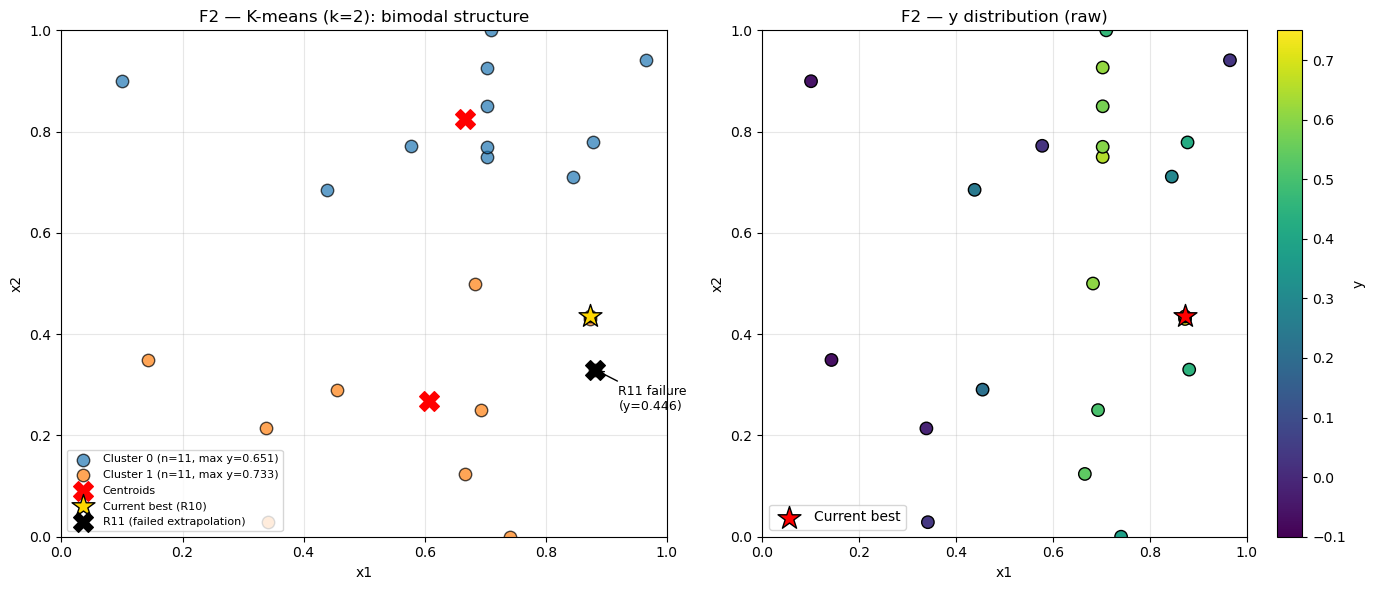

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: k=2 clusters
colors = ['#1f77b4', '#ff7f0e']
for i in range(2):
    members = labels2 == i
    ax1.scatter(X[members, 0], X[members, 1], 
                label=f'Cluster {i} (n={members.sum()}, max y={y[members].max():.3f})',
                s=80, color=colors[i], edgecolor='black', alpha=0.7)
ax1.scatter(km2.cluster_centers_[:, 0], km2.cluster_centers_[:, 1],
            marker='X', s=200, color='red', label='Centroids', zorder=5)
ax1.scatter(*X[y.argmax()], marker='*', s=300, color='gold', 
            edgecolor='black', label='Current best (R10)', zorder=6)

# Annotate the latest failure point
R11_query = np.array([0.8812, 0.3300])
ax1.scatter(*R11_query, marker='X', s=200, color='black', 
            label='R11 (failed extrapolation)', zorder=5)
ax1.annotate('R11 failure\n(y=0.446)', R11_query, 
             xytext=(0.92, 0.25), fontsize=9, 
             arrowprops=dict(arrowstyle='->', color='black'))

ax1.set_xlabel('x1'); ax1.set_ylabel('x2')
ax1.set_title('F2 — K-means (k=2): bimodal structure')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
ax1.legend(loc='lower left', fontsize=8); ax1.grid(alpha=0.3)

# Right: y heatmap
sc = ax2.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', 
                  s=80, edgecolor='black', vmin=-0.1, vmax=0.75)
plt.colorbar(sc, ax=ax2, label='y')
ax2.scatter(*X[y.argmax()], marker='*', s=300, color='red', 
            edgecolor='black', label='Current best')
ax2.set_xlabel('x1'); ax2.set_ylabel('x2')
ax2.set_title('F2 — y distribution (raw)')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.legend(loc='lower left'); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('F2_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

##### Step 4 — The inter-cluster valley

The new query at (0.881, 0.330) gave y = 0.446 — significantly lower  than either cluster's best. This is empirical evidence of a **valley between the two modes**.

A "bridge" probe would have to test multiple intermediate points to confirm whether the valley is uniform or whether a narrow ridge connects the modes.

In [ ]:
# Distance from the latest failure to each cluster centroid
for i in range(2):
    dist = np.linalg.norm(R11_query - km2.cluster_centers_[i])
    print(f"R11 failure point distance to cluster {i} centroid: {dist:.4f}")

# Y value at the latest query vs cluster means
R11_y = 0.4462  # from R11 result
print(f"\nR11 query y = {R11_y:.4f}")
print(f"  vs cluster 0 mean y = {y[labels2==0].mean():+.4f}, max y = {y[labels2==0].max():+.4f}")
print(f"  vs cluster 1 mean y = {y[labels2==1].mean():+.4f}, max y = {y[labels2==1].max():+.4f}")
print(f"\n→ R11 falls between clusters geographically but below both in y.")
print(f"  Evidence of an inter-modal valley.")

R11 failure point distance to cluster 0 centroid: 0.5405
R11 failure point distance to cluster 1 centroid: 0.2803

R11 query y = 0.4462
  vs cluster 0 mean y = +0.3506, max y = +0.6507
  vs cluster 1 mean y = +0.3729, max y = +0.7334

→ R11 falls between clusters geographically but below both in y.
  Evidence of an inter-modal valley.


##### Step 5 — Strategic implications

##### What clustering tells us about F2

1. **F2 is genuinely bimodal**, formally confirmed by K-means.
2. **The two modes are geographically separated** by an inter-cluster valley (sampled with probing).
3. **The GP cannot reliably interpolate across the valley** — GP-EI tried this and lost.
4. **The GP's length-scale pinning (x2 = 5.0) reflects the model's  inability to fit bimodal structure with stationary kernels** — 
   any single length scale either over-smooths the valley or under-smooths the modes.

##### Reflection

**Clusters identified?**: Two clearly separated clusters, each containing a known good region. K-means with k=2 has the highest silhouette score, formally validating the bimodal hypothesis.

**Less effective strategies**: Multi-dim moves on F2 have failed repeatedly. Single-dim probes within a mode are the only reliable approach. Trusting GP-EI's recommendations when they target inter-cluster space is unreliable.

**Parallel to clustering algorithms**: F2 is the example of K-means' core insight applied to optimization. The search space has *natural groupings* that the optimizer must respect. Trying to optimize across cluster boundaries is what K-means tells us not to do as it conflates distinct regions.

**Plotted trends**: The visualization shows two distinct hot spots separated by cooler territory. The failure points sits between them, illustrating that geographic interpolation does not imply value interpolation in multimodal functions.